In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## Install & Import Required Libraries

In [2]:
# Install required NLTK data (run once)
import nltk

nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
import re
import pandas as pd
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialise tools
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))


## Helper Function for Text Cleaning:

Implement a Helper Function as per Text Preprocessing Notebook and Complete the following pipeline.

# Build a Text Cleaning Pipeline

In [4]:
def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Cleans and preprocesses a single text string.

    Steps:
      1. Lowercase the text.
      2. Remove URLs (http/https links).
      3. Remove emojis and non-ASCII characters.
      4. Remove mentions (@user), hashtag symbols, punctuation & digits.
      5. Tokenise by splitting on whitespace.
      6. Remove English stopwords.
      7. Apply lemmatization (default) or stemming depending on `rule`.

    Parameters
    ----------
    text : str
        Raw input text.
    rule : str
        'lemmatize' (default) or 'stem'.

    Returns
    -------
    str
        Cleaned, space-joined token string.
    """
    # 1. Convert the input to lowercase
    data = text.lower()

    # 2. Remove URLs (http / https / www)
    data = re.sub(r"https?://\S+|www\.\S+", "", data)

    # 3. Remove emojis and non-ASCII characters
    emoji_pattern = re.compile(
        "["
        "\U0001f600-\U0001f64f"
        "\U0001f300-\U0001f5ff"
        "\U0001f680-\U0001f6ff"
        "\U0001f1e0-\U0001f1ff"
        "\U00002702-\U000027b0"
        "]+",
        flags=re.UNICODE,
    )

    data = emoji_pattern.sub("", data)

    # Also strip any remaining Unicode emoji-like patterns
    data = re.sub(r"[^\x00-\x7F]+", "", data)

    # 4. Remove all other unwanted characters
    #    – Twitter mentions (@user), hashtag symbol, punctuation, double spaces
    data = re.sub("@[A-Za-z0-9_]+", " ", data)  # mentions
    data = re.sub("#[A-Za-z0-9_]+", " ", data)  # hashtag symbol (keep the word)
    data = re.sub("[^0-9A-Za-z ]", " ", data)  # keep only lowercase letters & spaces
    data = re.sub(r"\s+", " ", data).strip()  # collapse multiple spaces

    # 5. Create tokens by splitting on whitespace
    tokens = data.split()

    # 6. Remove stopwords
    stop_words.update(["rt"])
    tokens = [t for t in tokens if t not in stop_words]

    # 7. Lemmatize or stem
    if rule == "lemmatize":
        tokens = [lemmatizer.lemmatize(t, pos="v") for t in tokens]
    elif rule == "stem":
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)


# Text Classification using Machine Learning Models


### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column.

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into training and testing sets.

4. **TF-IDF Vectorization**  
   Transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Train a Logistic Regression model and evaluate it using the test set.

### Step 1 – Load the Dataset

In [5]:
DATA_PATH = (
    "/content/drive/MyDrive/sem6-AIandML/worksheet8/trum_tweet_sentiment_analysis.csv"
)


df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.rename(columns={"Sentiment": "label"}, inplace=True)
print("\nLabel distribution:")
print(df["label"].value_counts())

df.head()


Shape: (1850123, 2)
Columns: ['text', 'Sentiment']

Label distribution:
label
0    1244211
1     605912
Name: count, dtype: int64


,text,label
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


### Step 2 – Text Cleaning & Tokenisation

In [6]:
# Drop rows where text or label is missing
df.dropna(subset=["text", "label"], inplace=True)

# Apply the cleaning pipeline to every tweet (lemmatization by default)
df["cleaned_text"] = df["text"].apply(
    lambda x: text_cleaning_pipeline(x, rule="lemmatize")
)

print("Sample cleaned tweets:")
df[["text", "cleaned_text"]].head(5)


Sample cleaned tweets:


,text,cleaned_text
0,RT @JohnLeguizamo: #trump not draining swamp b...,drain swamp taxpayer dollars trip advertise pr...
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play anti t...
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york via
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi piers morgan david beckham awful donald tru...
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,tech firm sue buzzfeed publish unverified trum...


### Step 3 – Train / Test Split

In [7]:
X = df["cleaned_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 80 % train – 20 % test
    random_state=42,
    stratify=y,  # keep class proportions in both splits
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 1480098
Testing  samples : 370025


### Step 4 – TF-IDF Vectorisation

In [8]:
# Fit the vectoriser ONLY on training data to avoid data leakage
tfidf = TfidfVectorizer(
    max_features=10000,  # keep the top 10 000 terms by TF-IDF score
    ngram_range=(1, 2),  # unigrams + bigrams
    sublinear_tf=True,  # apply log normalisation to term frequencies
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test  TF-IDF matrix shape:", X_test_tfidf.shape)


Train TF-IDF matrix shape: (1480098, 10000)
Test  TF-IDF matrix shape: (370025, 10000)


### Step 5 – Model Training & Evaluation

In [9]:
# Train Logistic Regression
clf = LogisticRegression(
    max_iter=1000,
    C=1.0,  # regularisation strength (smaller = stronger)
    solver="saga",
    random_state=42,
)
clf.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = clf.predict(X_test_tfidf)

# Evaluation
print("=" * 55)
print("         CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred))


         CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.95      0.94    248842
           1       0.90      0.86      0.88    121183

    accuracy                           0.92    370025
   macro avg       0.92      0.91      0.91    370025
weighted avg       0.92      0.92      0.92    370025



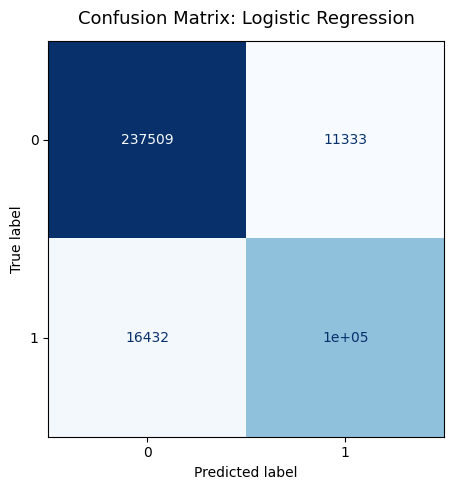

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Logistic Regression", fontsize=13, pad=12)
plt.tight_layout()
plt.show()
